# Pilot Workflow

Small first-pass inspection of the Hamburg building GeoPackage.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/raw/hamburg_buildings_clean.gpkg")
MAP_DIR = Path("../results/maps")
MAP_DIR.mkdir(parents=True, exist_ok=True)

gdf = gpd.read_file(DATA_PATH)
print("Buildings:", len(gdf))
print("CRS:", gdf.crs)
print("Columns:", gdf.columns.tolist())
gdf.head()


Buildings: 379320
CRS: EPSG:25832
Columns: ['gml_id', 'identifier', 'beginnt', 'advStandardModell', 'gebaeudefunktion', 'bauweise', 'anzahlDerOberirdischenGeschosse', 'dachform', 'grundflaeche', 'LI_Lineage', 'zeigtAuf', 'anlass', 'baujahr', 'hat', 'anzahlDerUnterirdischenGeschosse', 'AX_LI_ProcessStep_MitDatenerhebung_Description', 'AX_Datenerhebung', 'CharacterString', 'CI_RoleCode', 'weitereGebaeudefunktion', 'lageZurErdoberflaeche', 'dachart', 'name', 'LI_Source', 'hatDirektUnten', 'art', 'zeigtAufExternes|AA_Fachdatenverbindung|fachdatenobjekt|AA_Fachdatenobjekt|name', 'hochhaus', 'geometry']


,gml_id,identifier,beginnt,advStandardModell,gebaeudefunktion,bauweise,anzahlDerOberirdischenGeschosse,dachform,grundflaeche,LI_Lineage,...,weitereGebaeudefunktion,lageZurErdoberflaeche,dachart,name,LI_Source,hatDirektUnten,art,zeigtAufExternes|AA_Fachdatenverbindung|fachdatenobjekt|AA_Fachdatenobjekt|name,hochhaus,geometry
0,DEHHALKAz0000QCI,urn:adv:oid:DEHHALKAz0000QCI,2012-03-27T14:00:33Z,DLKM,1010,1100,1,3100,60,,...,NULL,NULL,NULL,NULL,NULL,None,None,None,None,"MULTIPOLYGON (((563708.097 5920218.985, 563711..."
1,DEHHALKAz0000Qj1,urn:adv:oid:DEHHALKAz0000Qj1,2012-03-27T14:00:33Z,DLKM,1010,1100,1,1000,146,,...,NULL,NULL,NULL,NULL,NULL,None,None,None,None,"MULTIPOLYGON (((563566.881 5920791.152, 563567..."
2,DEHHALKAz0000Tb0,urn:adv:oid:DEHHALKAz0000Tb0,2013-03-04T11:26:37Z,DLKM,1010,1100,1,3100,123,,...,NULL,NULL,NULL,NULL,NULL,None,None,None,None,"MULTIPOLYGON (((563147.087 5921886.412, 563148..."
3,DEHHALKAz0000QP3,urn:adv:oid:DEHHALKAz0000QP3,2012-03-27T14:00:33Z,DLKM,1010,1100,2,3200,114,,...,NULL,NULL,NULL,NULL,NULL,None,None,None,None,"MULTIPOLYGON (((563584.609 5921066.076, 563592..."
4,DEHHALKAz0000Qwm,urn:adv:oid:DEHHALKAz0000Qwm,2012-03-27T10:33:56Z,DLKM,1010,2200,2,3100,68,,...,NULL,NULL,NULL,NULL,NULL,None,None,None,None,"MULTIPOLYGON (((563020.916 5921961.907, 563027..."


In [2]:
gdf.dtypes


gml_id                                                                               object
identifier                                                                           object
beginnt                                                                              object
advStandardModell                                                                    object
gebaeudefunktion                                                                     object
bauweise                                                                             object
anzahlDerOberirdischenGeschosse                                                      object
dachform                                                                             object
grundflaeche                                                                         object
LI_Lineage                                                                           object
zeigtAuf                                                                        

In [3]:
gdf.geom_type.value_counts(dropna=False)


MultiPolygon    379320
Name: count, dtype: int64

## Gebaeudefunktion Coverage

Check how many buildings have the building-function attribute filled out.


In [4]:
gebaeudefunktion_values = gdf["gebaeudefunktion"].astype("string").str.strip()
gebaeudefunktion_filled = (
    gebaeudefunktion_values.notna()
    & gebaeudefunktion_values.ne("")
    & gebaeudefunktion_values.str.upper().ne("NULL")
)

gebaeudefunktion_coverage = pd.DataFrame({
    "metric": ["buildings_total", "gebaeudefunktion_filled", "gebaeudefunktion_missing"],
    "building_count": [
        len(gdf),
        int(gebaeudefunktion_filled.sum()),
        int((~gebaeudefunktion_filled).sum()),
    ],
})
gebaeudefunktion_coverage["share_pct"] = (
    gebaeudefunktion_coverage["building_count"] / len(gdf) * 100
).round(2)

display(gebaeudefunktion_coverage)

print("Most common gebaeudefunktion codes")
display(gebaeudefunktion_values.value_counts(dropna=False).head(15))


,metric,building_count,share_pct
0,buildings_total,379320,100.0
1,gebaeudefunktion_filled,379320,100.0
2,gebaeudefunktion_missing,0,0.0


Most common gebaeudefunktion codes


gebaeudefunktion
1010    205239
2463     60920
1313     40081
1120      9852
1100      8646
2140      6071
2020      5229
2465      4936
2740      2866
2120      2839
2010      2629
3021      2223
2720      1976
2050      1752
2520      1504
Name: count, dtype: Int64

## Most Common Gebaeudefunktion Codes

Create a donut chart of the most frequent building-function codes in the Hamburg building dataset.


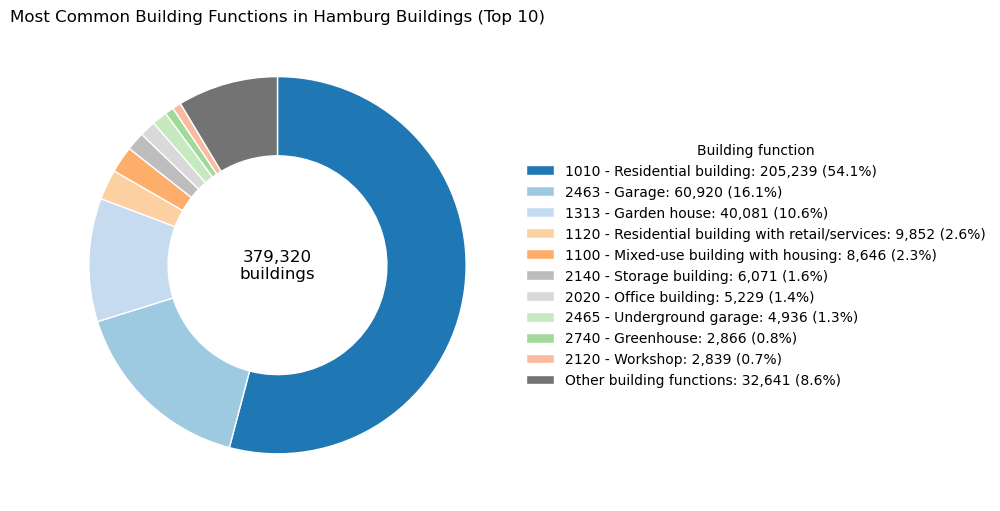

Output: ../results/maps/hamburg_most_common_gebaeudefunktion_donut.png


,gebaeudefunktion,label_en,building_count,share_pct
0,1010,1010 - Residential building,205239,54.1
1,2463,2463 - Garage,60920,16.1
2,1313,1313 - Garden house,40081,10.6
3,1120,1120 - Residential building with retail/services,9852,2.6
4,1100,1100 - Mixed-use building with housing,8646,2.3
5,2140,2140 - Storage building,6071,1.6
6,2020,2020 - Office building,5229,1.4
7,2465,2465 - Underground garage,4936,1.3
8,2740,2740 - Greenhouse,2866,0.8
9,2120,2120 - Workshop,2839,0.7


: 

In [ ]:
GEBAEUDEFUNKTION_LABELS_EN = {
    "1010": "Residential building",
    "2463": "Garage",
    "1313": "Garden house",
    "1120": "Residential building with retail/services",
    "1100": "Mixed-use building with housing",
    "2140": "Storage building",
    "2020": "Office building",
    "2465": "Underground garage",
    "2740": "Greenhouse",
    "2120": "Workshop",
    "2010": "Retail and service building",
    "3021": "General education school",
    "2720": "Agricultural/forestry operating building",
    "2050": "Shop",
    "2520": "Electricity supply building",
    "9998": "Not specified",
}

TOP_N = 10
function_counts = gebaeudefunktion_values.value_counts(dropna=False)
top_functions = function_counts.head(TOP_N).copy()
other_count = int(function_counts.iloc[TOP_N:].sum())

plot_counts = top_functions.copy()
if other_count > 0:
    plot_counts.loc["Other"] = other_count

plot_labels = [
    "Other building functions" if code == "Other" else f"{code} - {GEBAEUDEFUNKTION_LABELS_EN.get(str(code), 'Unmapped code')}"
    for code in plot_counts.index
]
plot_shares = (plot_counts / len(gdf) * 100).round(1)

other_colors = [
    "#9ecae1",
    "#c6dbef",
    "#fdd0a2",
    "#fdae6b",
    "#bdbdbd",
    "#d9d9d9",
    "#c7e9c0",
    "#a1d99b",
    "#fcbba1",
    "#e5e5e5",
]
plot_colors = []
other_color_index = 0
for code in plot_counts.index:
    if str(code) == "1010":
        plot_colors.append("#1f78b4")
    elif code == "Other":
        plot_colors.append("#737373")
    else:
        plot_colors.append(other_colors[other_color_index % len(other_colors)])
        other_color_index += 1

fig, ax = plt.subplots(figsize=(9, 7))
wedges, _ = ax.pie(
    plot_counts,
    colors=plot_colors,
    startangle=90,
    counterclock=False,
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 1},
)
ax.set_title(f"Most Common Building Functions in Hamburg Buildings (Top {TOP_N})")
ax.text(0, 0, f"{len(gdf):,}\nbuildings", ha="center", va="center", fontsize=12)

legend_labels = [
    f"{label}: {int(count):,} ({share:.1f}%)"
    for label, count, share in zip(plot_labels, plot_counts, plot_shares)
]
ax.legend(
    wedges,
    legend_labels,
    title="Building function",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
)
plt.tight_layout()

chart_path = MAP_DIR / "hamburg_most_common_gebaeudefunktion_donut.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Output:", chart_path)
display(
    pd.DataFrame({
        "gebaeudefunktion": [str(code) for code in plot_counts.index],
        "label_en": plot_labels,
        "building_count": plot_counts.astype(int).values,
        "share_pct": plot_shares.values,
    })
)
